In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
pd.set_option('display.max_columns',None)

In [6]:
df = pd.read_csv('/Users/garvit/Desktop/NestWise/4 - EDA/gurgaon_properties_missing_value_imputation.csv')
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,tulip ivory3.,sector 70,2.00,8333.0,4.0,5.0,3+,6.0,Moderately Old,2114.0,0,1,0,0,0,1,95
1,flat,capital residences 360,sector 70a,1.69,8553.0,3.0,3.0,3+,8.0,New Property,1900.0,0,1,0,0,0,0,165
2,flat,emaar palm premier,sector 77,2.10,10500.0,3.0,4.0,3+,11.0,New Property,1600.0,0,1,0,0,0,1,129
3,flat,m3m merlin3.,sector 67,2.65,12946.0,3.0,3.0,3,0.0,Relatively New,2047.0,0,0,0,0,1,1,174
4,flat,dnha group housing society,manesar,0.75,4518.0,3.0,2.0,2,5.0,Moderately Old,1502.0,0,0,0,0,0,0,0


In [7]:
df.shape

(3568, 18)

# for base line model

we will be dropping price_per_sqft, strong colinearity with price, 2nd we will be asking the user for just the price, not price_per_sqft so, it won't matter 
also, dropping society, if the user already know in which society he/she wants a flat to they can simply go there




In [9]:
train_df =  df.drop(columns = ['society','price_per_sqft'])

In [10]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,sector 70,2.00,4.0,5.0,3+,6.0,Moderately Old,2114.0,0,1,0,0,0,1,95
1,flat,sector 70a,1.69,3.0,3.0,3+,8.0,New Property,1900.0,0,1,0,0,0,0,165
2,flat,sector 77,2.10,3.0,4.0,3+,11.0,New Property,1600.0,0,1,0,0,0,1,129
3,flat,sector 67,2.65,3.0,3.0,3,0.0,Relatively New,2047.0,0,0,0,0,1,1,174
4,flat,manesar,0.75,3.0,2.0,2,5.0,Moderately Old,1502.0,0,0,0,0,0,0,0


### now our aim is find/select feature which accurately/closely justify the price, i.e we need feature selection

# luxury score

-> since it's our feature, our model don't know what 50 score means or what 120 score means, rather what we can do is make this numerical col categorical so. "low luxury", "medium luxury" and "high luxury"

<Axes: xlabel='luxury_score'>

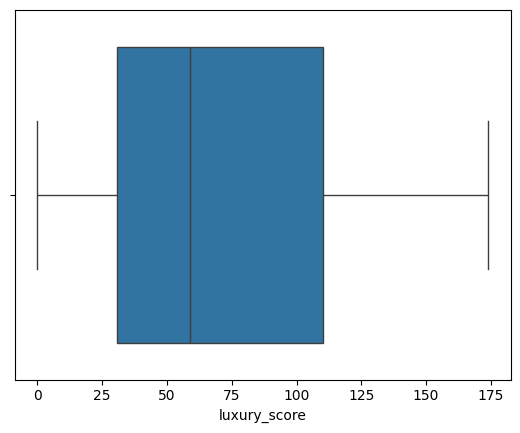

In [11]:
sns.boxplot(x=df['luxury_score'])

In [13]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score <150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None

In [14]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

In [15]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category
0,flat,sector 70,2.00,4.0,5.0,3+,6.0,Moderately Old,2114.0,0,1,0,0,0,1,95,Medium
1,flat,sector 70a,1.69,3.0,3.0,3+,8.0,New Property,1900.0,0,1,0,0,0,0,165,High
2,flat,sector 77,2.10,3.0,4.0,3+,11.0,New Property,1600.0,0,1,0,0,0,1,129,Medium
3,flat,sector 67,2.65,3.0,3.0,3,0.0,Relatively New,2047.0,0,0,0,0,1,1,174,High
4,flat,manesar,0.75,3.0,2.0,2,5.0,Moderately Old,1502.0,0,0,0,0,0,0,0,Low


### similarly we can do this for floor, we wont' be asking the user on which floor they want a flat/appartment, rather we can have category as "Low floor", "Mid Floor" and "High Floor"

<Axes: xlabel='floorNum'>

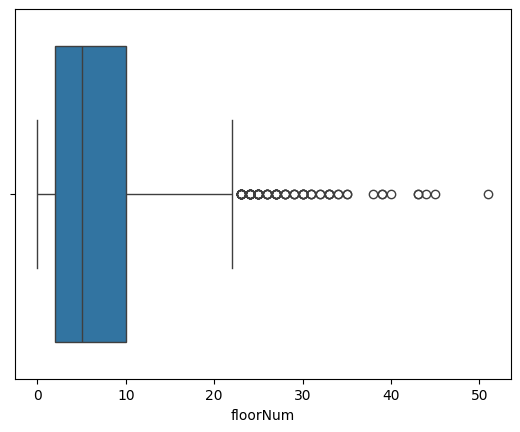

In [16]:
sns.boxplot(x=df['floorNum'])

In [17]:
def categorize_floor(floor):
    if 0<= floor <=2 :
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None

In [18]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [19]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,flat,sector 70,2.00,4.0,5.0,3+,6.0,Moderately Old,2114.0,0,1,0,0,0,1,95,Medium,Mid Floor
1,flat,sector 70a,1.69,3.0,3.0,3+,8.0,New Property,1900.0,0,1,0,0,0,0,165,High,Mid Floor
2,flat,sector 77,2.10,3.0,4.0,3+,11.0,New Property,1600.0,0,1,0,0,0,1,129,Medium,High Floor
3,flat,sector 67,2.65,3.0,3.0,3,0.0,Relatively New,2047.0,0,0,0,0,1,1,174,High,Low Floor
4,flat,manesar,0.75,3.0,2.0,2,5.0,Moderately Old,1502.0,0,0,0,0,0,0,0,Low,Mid Floor


In [20]:
train_df.drop(columns = ['floorNum','luxury_score'],inplace=True)

In [21]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,flat,sector 70,2.00,4.0,5.0,3+,Moderately Old,2114.0,0,1,0,0,0,1,Medium,Mid Floor
1,flat,sector 70a,1.69,3.0,3.0,3+,New Property,1900.0,0,1,0,0,0,0,High,Mid Floor
2,flat,sector 77,2.10,3.0,4.0,3+,New Property,1600.0,0,1,0,0,0,1,Medium,High Floor
3,flat,sector 67,2.65,3.0,3.0,3,Relatively New,2047.0,0,0,0,0,1,1,High,Low Floor
4,flat,manesar,0.75,3.0,2.0,2,Moderately Old,1502.0,0,0,0,0,0,0,Low,Mid Floor


NOW OUR MODEL WON'T UNDERSTAND WHAT FLAT/HOUSE etc are simlar what luxrury Medium, low and high mean.. so we can convert this categorical data into number like flats can we represented as 0, houses 1. 
it's better for our model --- how ordinalEncoder in sklearn.preporcessing

In [23]:
!pip install scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 22.5 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.7/20.7 MB 19.6 MB/s eta 0:00:0000:0100:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


In [24]:
from sklearn.preprocessing import OrdinalEncoder

data_label_encoded = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns
print(categorical_cols)

for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

X_label = data_label_encoded.drop('price',axis=1)
y_label = data_label_encoded['price']


Index(['property_type', 'sector', 'balcony', 'agePossession',
       'luxury_category', 'floor_category'],
      dtype='object')
[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'new',
       'new sector 2', 'sector 1', 'sector 102', 'sector 103',
       'sector 104', 'sector 105', 'sector 106', 'sector 107',
       'sector 108', 'sector 109', 'sector 10a', 'sector 11',
       'sector 110', 'sector 111', 'sector 112', 'sector 113',
       'sector 12', 'sector 13', 'sector 14', 'sector 15', 'sector 17',
       'sector 17a', 'sector 17b', 'sector 2', 'sector 21', 'sector 22',
       'sector 23', 'sector 24', 'sector 25', 'sector 26', 'sector 27',
       'sector 28', 'sector 3', 'sector 3 phase 2',
       'sector 3 phase 3 extension', 'sector 30', 'sector 31',
       'sector 33', 'sector 33 road', 'sector 36', 'sector 36 road',
       'sector 36a', 'sector 37', 'sector 37c', 'sector 37d', 'sector 38',
       'sector 39', 'sector 4', 'sector 4

In [25]:
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,84.0,4.0,5.0,4.0,0.0,2114.0,0,1,0,0,0,1,2.0,2.0
1,0.0,85.0,3.0,3.0,4.0,1.0,1900.0,0,1,0,0,0,0,0.0,2.0
2,0.0,91.0,3.0,4.0,4.0,1.0,1600.0,0,1,0,0,0,1,2.0,0.0
3,0.0,79.0,3.0,3.0,3.0,3.0,2047.0,0,0,0,0,1,1,0.0,1.0
4,0.0,2.0,3.0,2.0,2.0,0.0,1502.0,0,0,0,0,0,0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3563,1.0,27.0,6.0,6.0,2.0,0.0,3611.0,0,0,0,0,0,0,1.0,1.0
3564,0.0,54.0,3.0,3.0,4.0,2.0,1385.0,0,0,1,0,0,1,0.0,2.0
3565,1.0,13.0,5.0,6.0,4.0,0.0,2430.0,0,1,0,0,0,0,1.0,1.0
3566,0.0,101.0,4.0,6.0,3.0,3.0,3920.0,0,1,0,0,0,0,0.0,2.0


In [28]:
X_label['study room'].astype('float')

0       0.0
1       0.0
2       0.0
3       0.0
4       0.0
       ... 
3563    0.0
3564    0.0
3565    0.0
3566    0.0
3567    0.0
Name: study room, Length: 3568, dtype: float64

In [29]:
X_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,0.0,84.0,4.0,5.0,4.0,0.0,2114.0,0,1,0,0,0,1,2.0,2.0
1,0.0,85.0,3.0,3.0,4.0,1.0,1900.0,0,1,0,0,0,0,0.0,2.0
2,0.0,91.0,3.0,4.0,4.0,1.0,1600.0,0,1,0,0,0,1,2.0,0.0
3,0.0,79.0,3.0,3.0,3.0,3.0,2047.0,0,0,0,0,1,1,0.0,1.0
4,0.0,2.0,3.0,2.0,2.0,0.0,1502.0,0,0,0,0,0,0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3563,1.0,27.0,6.0,6.0,2.0,0.0,3611.0,0,0,0,0,0,0,1.0,1.0
3564,0.0,54.0,3.0,3.0,4.0,2.0,1385.0,0,0,1,0,0,1,0.0,2.0
3565,1.0,13.0,5.0,6.0,4.0,0.0,2430.0,0,1,0,0,0,0,1.0,1.0
3566,0.0,101.0,4.0,6.0,3.0,3.0,3920.0,0,1,0,0,0,0,0.0,2.0


In [31]:
y_label

0       2.00
1       1.69
2       2.10
3       2.65
4       0.75
        ... 
3563    5.00
3564    1.50
3565    6.10
3566    2.20
3567    1.25
Name: price, Length: 3568, dtype: float64

# Feature Selection 

-> i'll apply 8 feature selection technique, say findind correlation etc, each technique will be given a score to every feature, at the end we will combine these score sum or take avg, then which every feature has significant value will be given more importance

## Technique 1 : Correlation Analysis

<Axes: >

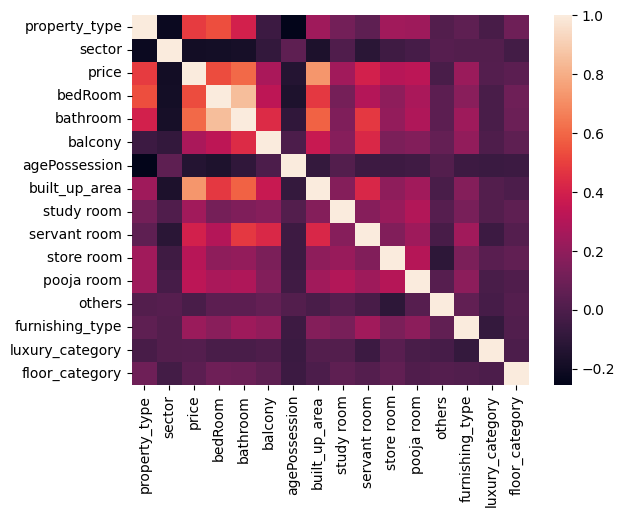

In [32]:
sns.heatmap(data_label_encoded.corr())

In [33]:
fi_df1 = data_label_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1

,feature,corr_coeff
0,sector,-0.196366
1,price,1.000000
2,bedRoom,0.529711
3,bathroom,0.605765
4,balcony,0.271314
5,agePossession,-0.135589
6,built_up_area,0.729304
7,study room,0.244908
8,servant room,0.397098
9,store room,0.312824


# Technique 2 - Random Forest Feature Importance

In [34]:
from sklearn.ensemble import RandomForestRegressor

rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label,y_label)

fi_df2 = pd.DataFrame({
    'feature' : X_label.columns,
    'rf_importance' : rf_label.feature_importances_
}).sort_values(by='rf_importance',ascending=False)

fi_df2

,feature,rf_importance
6,built_up_area,0.629543
0,property_type,0.102871
1,sector,0.101747
3,bathroom,0.036710
8,servant room,0.024607
2,bedRoom,0.022998
5,agePossession,0.014735
12,furnishing_type,0.012697
4,balcony,0.011959
7,study room,0.009545


# Technique 3 : Gradient Boosting Feature Importances

In [35]:
from sklearn.ensemble import GradientBoostingRegressor

gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
6,built_up_area,0.668279
1,sector,0.104121
0,property_type,0.102831
3,bathroom,0.044547
2,bedRoom,0.028086
8,servant room,0.024842
9,store room,0.011621
5,agePossession,0.003965
12,furnishing_type,0.003859
7,study room,0.003003


# Technique 4 - Permutation Importance

In [36]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
6,built_up_area,0.609819
0,property_type,0.212072
1,sector,0.172047
8,servant room,0.015956
3,bathroom,0.015405
2,bedRoom,0.010963
7,study room,0.006258
13,luxury_category,0.004656
5,agePossession,0.004518
12,furnishing_type,0.003202


# Technique 5 LASSO

In [37]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5

,feature,lasso_coeff
6,built_up_area,1.466400
0,property_type,0.802933
3,bathroom,0.482293
9,store room,0.209178
12,furnishing_type,0.180800
7,study room,0.175349
8,servant room,0.150551
10,pooja room,0.086552
13,luxury_category,0.054136
5,agePossession,-0.000413
